Day 0 start:      2024-12-02 00:00:00
First timestamp:  2024-12-02 18:40:58.296000
Last timestamp:   2025-02-08 17:23:41.984000

Experiment start: 2024-12-07 00:00:00
Experiment end:   2025-02-07 00:00:00
day1+, cold starts: 46121


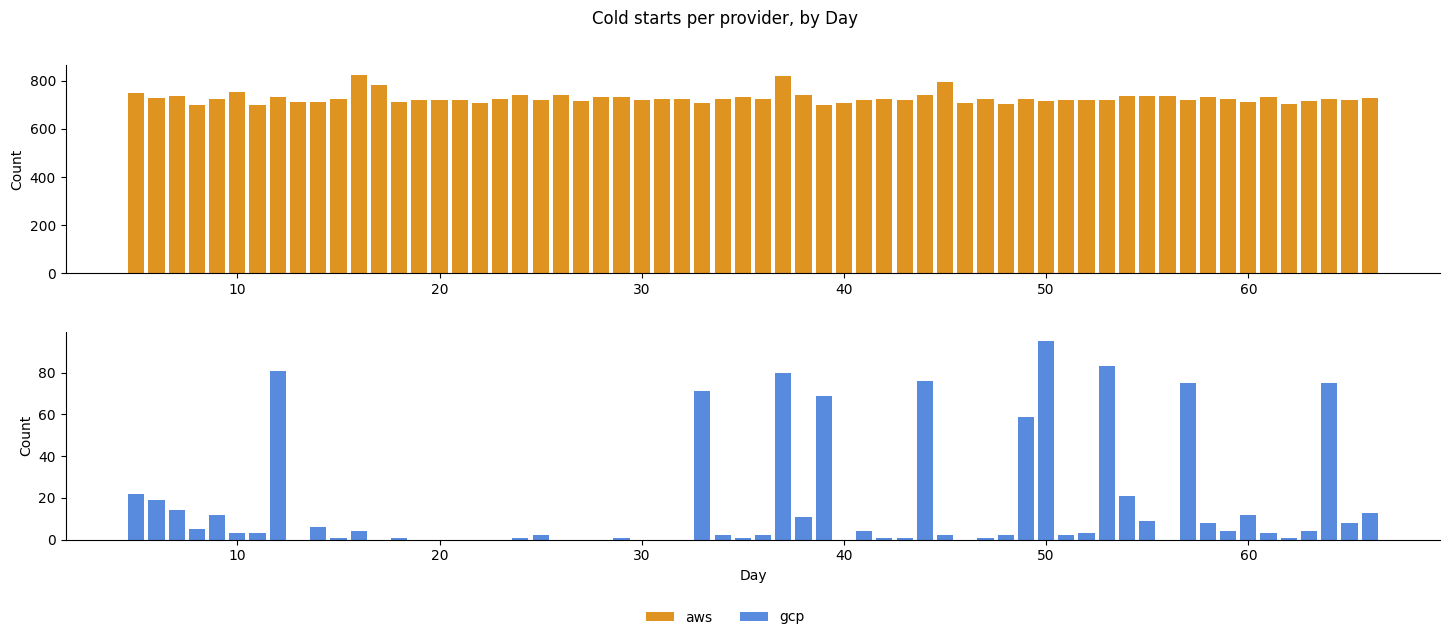

In [4]:
from datetime import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.reset_defaults()
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
pickle_df = pd.read_pickle('../stats-all-latest.pkl')

millis_in_day = 1000 * 60 * 60 * 24
expected_datapoints_in_day = 24 * 12 * 2 * 2 * 3 * 3 * 3 # hours * executions * clouds * images * formats * widths * memory

# First and last executions, timestamp is in millis
min_ts = pickle_df["timestamp"].min()
max_ts = pickle_df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day

print(f'Day 0 start:      {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp:  {dt.fromtimestamp(min_ts/1000)}')
print(f'Last timestamp:   {dt.fromtimestamp(max_ts/1000)}')
print('')

# start_ts = 1733184000000 # Tue Dec 03 2024 00:00:00 GMT+0000
# end_ts   = 1738540800000 # Mon Feb 03 2025 00:00:00 GMT+0000
start_ts = 1733529600000 # Sat Dec 07 2024 00:00:00 GMT+0000
end_ts   = 1738886400000 # Fri Feb 07 2025 00:00:00 GMT+0000
print(f'Experiment start: {dt.fromtimestamp(start_ts/1000)}')
print(f'Experiment end:   {dt.fromtimestamp(end_ts/1000)}')

df = pickle_df.loc[(pickle_df['timestamp'] >= start_ts) & (pickle_df['timestamp'] < end_ts)].copy()
df.loc[:, 'isoDate'] = pd.to_datetime(df['!isoDate']) 
df = df.set_index("isoDate").sort_index()
df["day"] = (df['timestamp'] - day_0) // millis_in_day
df["dom"] = df.index.day
df["dow"] = df.index.day_of_week
df["day_name"] = df.index.day_name()
df["hod"] = df.index.hour
df["moh"] = df.index.minute
df["how"] = df["dow"] * 24 + df["hod"]
df["msm"] = df.index.hour * 60 + (df.index.minute)

# Cold starts only
coldStarts = df.dropna(subset=['coldStart'])
print('day1+, cold starts:', len(coldStarts))

# Create the catplot with 'providerName' as row and hue
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='day',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=4.5,
    height=3,
    native_scale=True,
    sharex='row',
    sharey=False,
)
plt.suptitle('Cold starts per provider, by Day')
plt.tight_layout()
sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set_titles('')
g.set_xlabels('Day')
g.set_ylabels('Count')
g.savefig(f'../graphs/5-cold-starts.pdf', bbox_inches='tight')
plt.show()
plt.close()

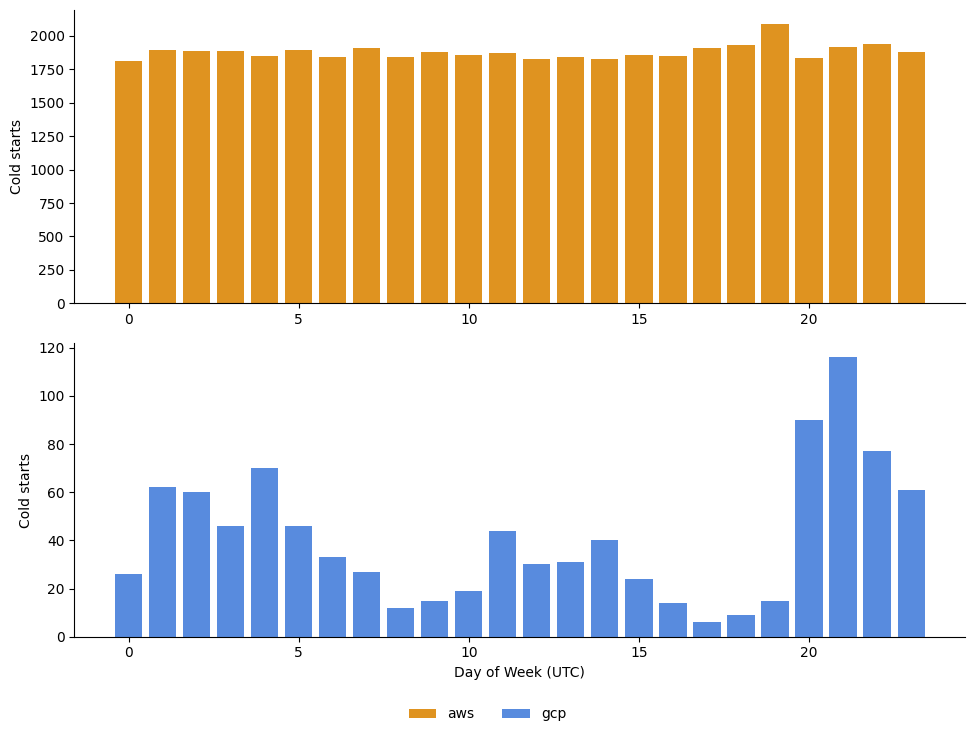

In [36]:
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='hod',
    # order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex=False,
    sharey=False,
)
sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set_titles('')
g.set_xlabels('Day of Week (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Day of Week (UTC)')
plt.tight_layout()
plt.show()

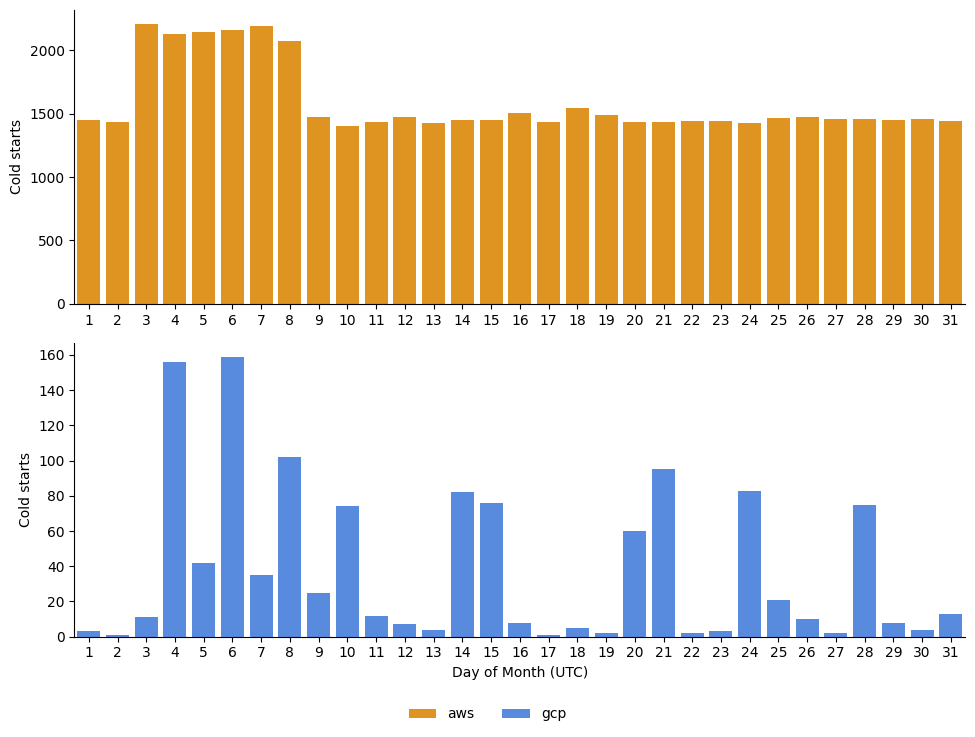

In [4]:
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='dom',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex=False,
    sharey=False,
)

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set(xticks=range(0, 32, 1), xlim=(0.5, 31.5))
g.set_titles('')
g.set_xlabels('Day of Month (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Day of Month (UTC)')
plt.tight_layout()
plt.show()

In [ ]:
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='dom',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex=False,
    sharey=False,
)

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set(xticks=range(0, 32, 1), xlim=(0.5, 31.5))
g.set_titles('')
g.set_xlabels('Day of Month (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Day of Month (UTC)')
plt.tight_layout()
plt.show()

1924484


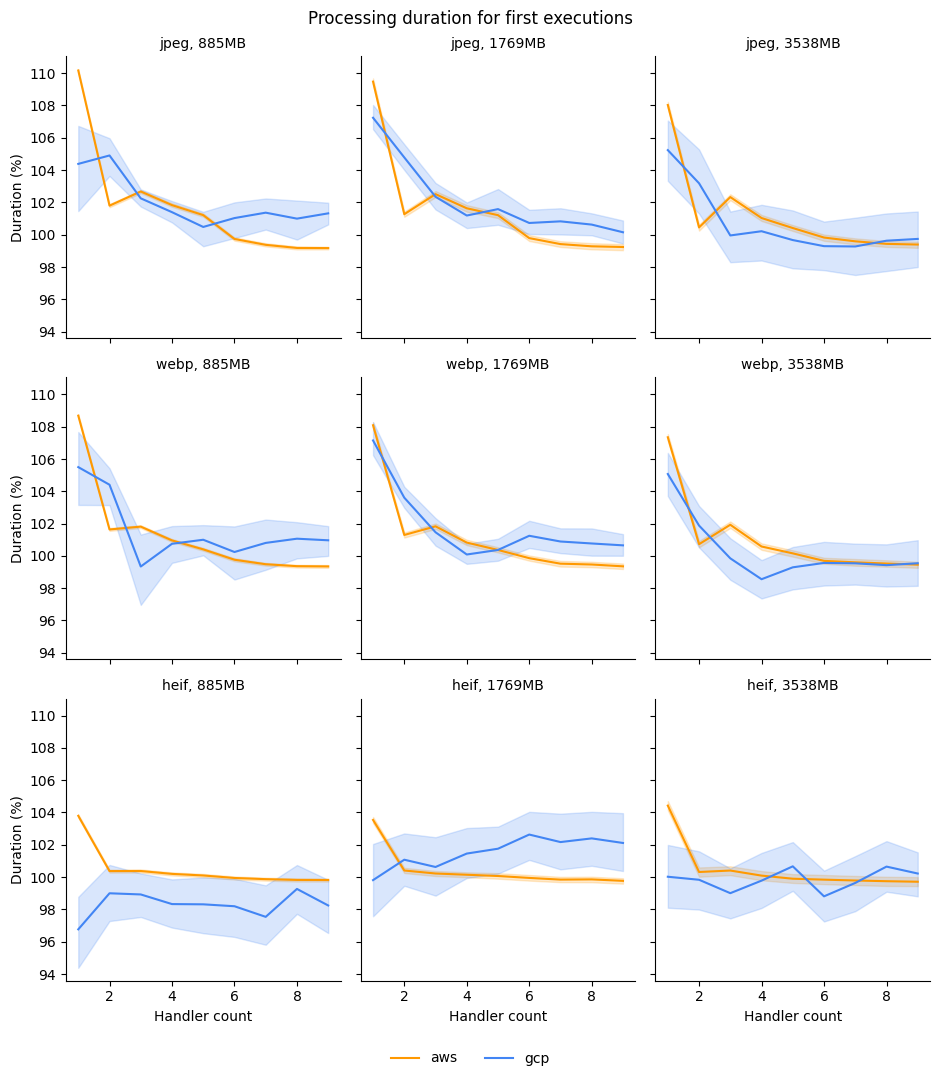

In [12]:
print(len(df))

# Calculate average durations for normalization and merge
average_durations = df.groupby(['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName'])['durationProcessingMs'].mean().reset_index()
average_durations = average_durations.rename(columns={'durationProcessingMs': 'average_durationProcessingMs'})
data_merged = pd.merge(df, average_durations, on=['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName'])
data_merged['normalized_durationProcessingMs'] = (data_merged['durationProcessingMs'] / data_merged['average_durationProcessingMs']) * 100

data2 = data_merged.loc[(data_merged['handlerCount'] < 10)]

g = sns.relplot(
    data=data2,
    kind='line',
    x='handlerCount',
    y='normalized_durationProcessingMs',
    hue='providerName',   # Keep providerName for color differentiation
    palette=colors,       # Use the defined colors
    row='outputFormat',   # Separate rows for each provider
    col='providerMemoryAssociated',
    # style='outputWidth',
    row_order=['jpeg', 'webp', 'heif'],
    aspect=0.8,
    height=3.5,
    # facet_kws={'sharey': 'row'},
)

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
g.set_titles("{row_name}, {col_name}MB")
g.set_xlabels('Handler count')
g.set_ylabels('Duration (%)')
# [ax.set(xlabel='handlerCounterrr') for sublist in g.axes for ax in sublist] , use with facet_kws={'sharex': False, 'sharey': 'row'}, for relplot
plt.suptitle(f'Processing duration for first executions')
plt.tight_layout()
plt.show()

23980 aws


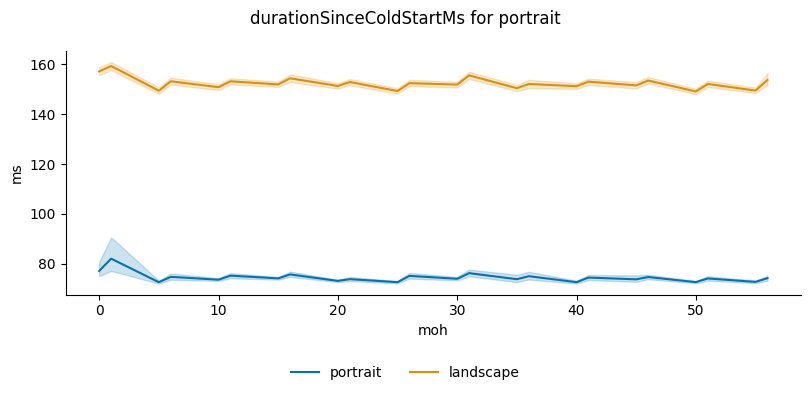

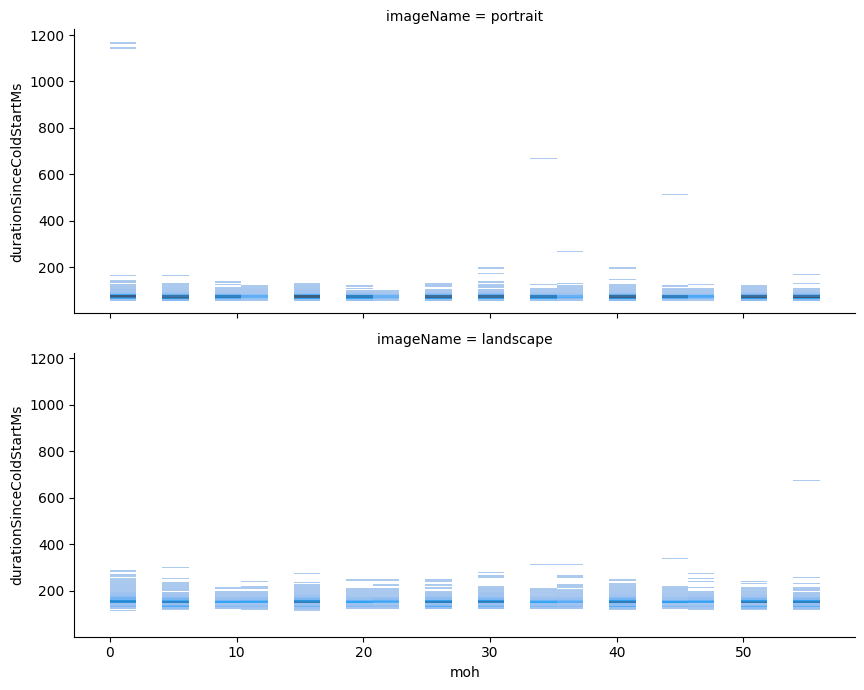

11 gcp


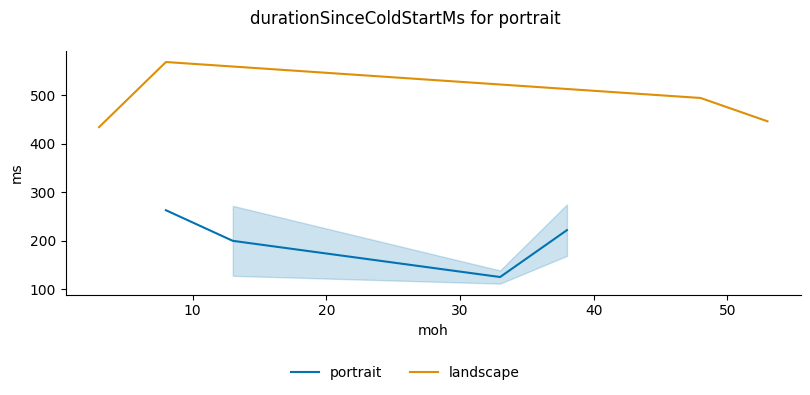

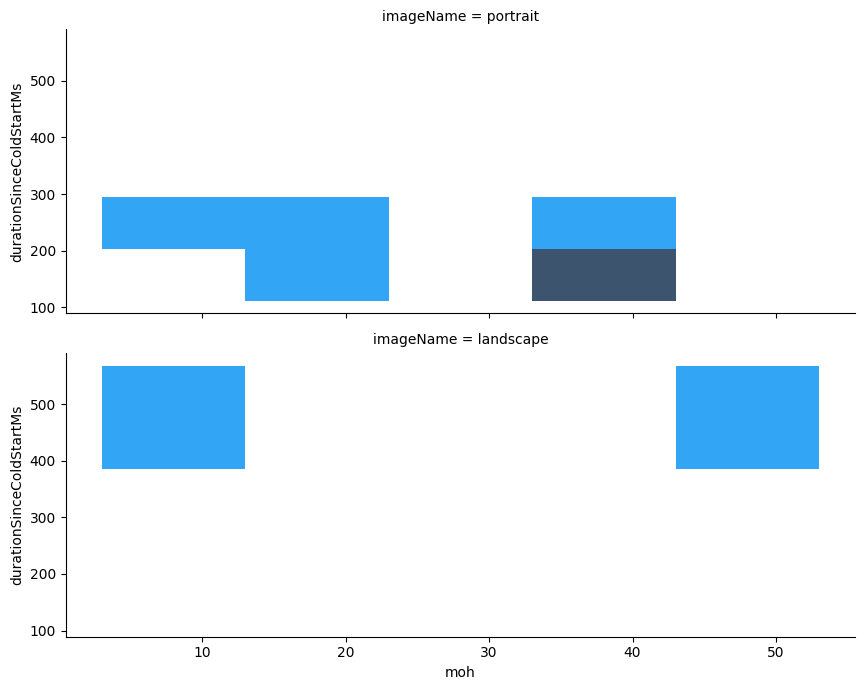

In [6]:
# plot cold start duration (y=durationSinceColdStartMs) by hour of day (hod)
from IPython.display import display, HTML

# print(len(coldStarts))
# display(HTML(data.head(100).to_html()))
# remove entries in data with handlerCount >5
firstExecutions = data[data['handlerCount'] <= 1]
firstExecutions = firstExecutions[firstExecutions['durationSinceColdStartMs'] <= 1200]
# display(HTML(result.head(100).to_html()))


# for imageName in ["landscape", "portrait"]:
for providerName in ['aws', 'gcp']:
    # data2 = firstExecutions.loc[(firstExecutions["imageName"] == imageName) & (firstExecutions['providerName'] == 'aws')]
    data2 = firstExecutions.loc[(firstExecutions['providerName'] == providerName)]
    print(len(data2), providerName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='moh',
        y='durationSinceColdStartMs',
        hue='imageName',   # Keep providerName for color differentiation
        # palette=colors,       # Use the defined colors
        palette='colorblind',       # Use the defined colors
        # row='outputFormat',   # Separate rows for each provider
        # col='providerMemoryAssociated',
        # style='',
        # row_order=['jpeg', 'webp', 'heif'],
        aspect=2,
        height=3.5,
        # facet_kws={'sharey': 'row'},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    # g.set_titles("{row_name}, {col_name}MB")
    # g.set_xlabels('Hour of Day (UTC)')
    g.set_ylabels('ms')
    # [ax.set(xlabel='handlerCounterrr') for sublist in g.axes for ax in sublist] , use with facet_kws={'sharex': False, 'sharey': 'row'}, for relplot
    plt.suptitle(f'durationSinceColdStartMs for {imageName}')
    plt.tight_layout()
    plt.show()

    g = sns.displot(
        data=data2,
        x="moh",
        y='durationSinceColdStartMs',
        # hue='imageName',   # Keep providerName for color differentiation
        row='imageName',   # Separate rows for each provider
        # palette=colors,       # Use the defined colors
        aspect=2.5,
        height=3.5,
        # col="time",
        # kde=True,
        facet_kws={'sharey': False},
    )
    plt.show()
